#ELECTRIC VEHICLES ANALYSIS 2020-2026

##IMPORT LIBRARIES

In [1]:
#Importing Libararies 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##LAODING DATASET

In [2]:
#Importing dataset
df= pd.read_csv(r"C:\Users\welcome\OneDrive\Desktop\EV projects\ev_market_2026.csv")
df.head()

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
0,Volkswagen,ID. Buzz,2023,Performance,104880.80,118.7,400.0,234.5,3.04,195.0,...,Truck,54.2,2015.0,4,2,Germany,Luxury,202182,4.00,4
1,Toyota,bZ Compact SUV,2022,Premium,48217.41,58.8,219.0,148.1,5.77,159.0,...,SUV,69.0,1709.0,4,0,Japan,Mid-range,7146,3.56,3
2,GM/Chevrolet,Bolt EV,2024,Premium,49651.12,58.2,225.0,104.9,6.84,148.0,...,Van,77.0,1533.0,4,1,US,Mid-range,16590,3.70,3
3,Kia,Sportage EV,2024,Long Range,38131.56,102.5,349.0,66.5,4.66,176.0,...,SUV,65.8,1935.0,4,2,South Korea,Mid-range,127201,3.81,3
4,Tesla,Model 3,2022,Long Range,144079.87,93.9,314.0,298.5,5.64,165.0,...,SUV,38.3,2229.0,4,2,US,Luxury,196401,3.83,4


##RAW DATA EXPLORATION

In [3]:
#Shape of dataset
df.shape

(2000, 24)

In [4]:
#Size of dataset
df.size

48000

In [5]:
#details of dataset
df.info

<bound method DataFrame.info of              brand           model  year      variant  price_usd  \
0       Volkswagen        ID. Buzz  2023  Performance  104880.80   
1           Toyota  bZ Compact SUV  2022      Premium   48217.41   
2     GM/Chevrolet         Bolt EV  2024      Premium   49651.12   
3              Kia     Sportage EV  2024   Long Range   38131.56   
4            Tesla         Model 3  2022   Long Range  144079.87   
...            ...             ...   ...          ...        ...   
1995           BMW              i3  2023   Long Range  122665.71   
1996        Toyota            bZ4X  2024  Performance   66816.55   
1997         Tesla         Model 3  2025   Long Range   49281.26   
1998         Tesla         Model X  2026      Premium  139665.73   
1999           BYD             Qin  2025      Premium   47547.88   

      battery_capacity_kwh  range_miles  charging_speed_kw  \
0                    118.7        400.0              234.5   
1                     58.8 

##DATA QUALITY ASSESSMENT

In [21]:
#checking null values
df.isnull().sum()

brand                    0
model                    0
year                     0
variant                  0
price_usd                0
battery_capacity_kwh     0
range_miles              0
charging_speed_kw        0
acceleration_0_60_mph    0
top_speed_mph            0
horsepower               0
torque_nm                0
drive_type               0
seating_capacity         0
body_type                0
cargo_volume_cubic_ft    0
weight_kg                0
safety_rating            0
autopilot_level          0
country_of_origin        0
market_segment           0
annual_sales_units       0
customer_rating          0
warranty_years           0
dtype: int64

In [20]:
#checking duplicate values
df.duplicated().sum()

np.int64(0)

In [8]:
#listing columns names
df.columns

Index(['brand', 'model', 'year', 'variant', 'price_usd',
       'battery_capacity_kwh', 'range_miles', 'charging_speed_kw',
       'acceleration_0_60_mph', 'top_speed_mph', 'horsepower', 'torque_nm',
       'drive_type', 'seating_capacity', 'body_type', 'cargo_volume_cubic_ft',
       'weight_kg', 'safety_rating', 'autopilot_level', 'country_of_origin',
       'market_segment', 'annual_sales_units', 'customer_rating',
       'warranty_years'],
      dtype='str')

In [19]:
#checking data types of all columns
df.dtypes

brand                        str
model                        str
year                       int64
variant                      str
price_usd                float64
battery_capacity_kwh     float64
range_miles              float64
charging_speed_kw        float64
acceleration_0_60_mph    float64
top_speed_mph            float64
horsepower               float64
torque_nm                float64
drive_type                   str
seating_capacity           int64
body_type                    str
cargo_volume_cubic_ft    float64
weight_kg                float64
safety_rating              int64
autopilot_level            int64
country_of_origin            str
market_segment               str
annual_sales_units         int64
customer_rating          float64
warranty_years             int64
dtype: object

In [11]:
print('Statistical Summary: ')
df.describe()

Statistical Summary: 


,year,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,horsepower,torque_nm,seating_capacity,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,annual_sales_units,customer_rating,warranty_years
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2024.028500,78873.907150,74.662800,261.825500,155.206300,5.630635,164.884500,665.744000,601.311500,5.747000,46.105850,1886.164500,4.377000,1.124500,129653.592000,3.572045,4.579000
std,1.410561,35296.621782,20.082879,71.028238,80.982301,1.417733,20.781244,267.124838,238.706686,1.045245,19.850264,383.772906,0.661127,0.919469,105775.154465,0.270398,1.218812
min,2020.000000,16394.330000,40.000000,150.000000,50.000000,2.500000,118.000000,150.000000,200.000000,2.000000,15.000000,1500.000000,3.000000,0.000000,656.000000,3.000000,3.000000
25%,2023.000000,52325.920000,58.475000,204.000000,90.975000,4.620000,148.000000,442.750000,391.750000,5.000000,28.175000,1570.000000,4.000000,0.000000,44296.500000,3.380000,4.000000
50%,2024.000000,73013.015000,75.100000,261.000000,132.100000,5.670000,165.000000,683.000000,615.500000,5.000000,41.250000,1740.500000,4.000000,1.000000,111188.000000,3.560000,4.000000
75%,2025.000000,99780.157500,87.550000,310.000000,217.300000,6.770000,181.000000,939.250000,845.000000,7.000000,64.700000,2149.500000,5.000000,2.000000,202496.750000,3.750000,5.000000
max,2026.000000,269775.200000,119.900000,447.000000,349.900000,8.000000,200.000000,1000.000000,988.000000,7.000000,80.000000,3000.000000,5.000000,3.000000,499717.000000,4.510000,8.000000


###RANGE VALIDATION

In [24]:
#Checking range
print(df["year"].min(), df["year"].max())
print(df["price_usd"].min(), df["price_usd"].max())
print(df["battery_capacity_kwh"].min(), df["battery_capacity_kwh"].max())
print(df["range_miles"].min(), df["range_miles"].max())
print(df["horsepower"].min(), df["horsepower"].max())
print(df["weight_kg"].min(), df["weight_kg"].max())

2020 2026
16394.33 269775.2
40.0 119.9
150.0 447.0
150.0 1000.0
1500.0 3000.0


###CATEGORICAL CONSISTENCY CHECK

In [ ]:
#Checking categorical columns
print(df["brand"].unique())
print(df["variant"].unique())
print(df["drive_type"].unique())
print(df["body_type"].unique())
print(df["country_of_origin"].unique())
print(df["market_segment"].unique())

<ArrowStringArray>
[  'Volkswagen',       'Toyota', 'GM/Chevrolet',          'Kia',
        'Tesla',     'Mercedes',       'Fisker',          'BYD',
      'Hyundai',         'Ford',          'BMW',         'Audi',
          'NIO',       'Rivian',      'Porsche',        'Volvo',
        'Lucid',        'Honda',       'Xiaomi',     'Polestar']
Length: 20, dtype: str
<ArrowStringArray>
['Performance', 'Premium', 'Long Range', 'Base', 'Standard']
Length: 5, dtype: str
<ArrowStringArray>
['AWD', 'FWD', 'RWD']
Length: 3, dtype: str
<ArrowStringArray>
['Truck', 'SUV', 'Van', 'Hatchback', 'Coupe', 'Sedan']
Length: 6, dtype: str
<ArrowStringArray>
['Germany', 'Japan', 'US', 'South Korea', 'China', 'Sweden']
Length: 6, dtype: str
<ArrowStringArray>
['Luxury', 'Mid-range', 'Premium', 'Budget']
Length: 4, dtype: str


In [ ]:
#Checking counts of Categorical data
df["brand"].value_counts()
df["variant"].value_counts()
df["drive_type"].value_counts()
df["body_type"].value_counts()
df["country_of_origin"].value_counts()
df["market_segment"].value_counts()

market_segment
Premium      712
Mid-range    642
Luxury       495
Budget       151
Name: count, dtype: int64

##OUTLIER DETECTION

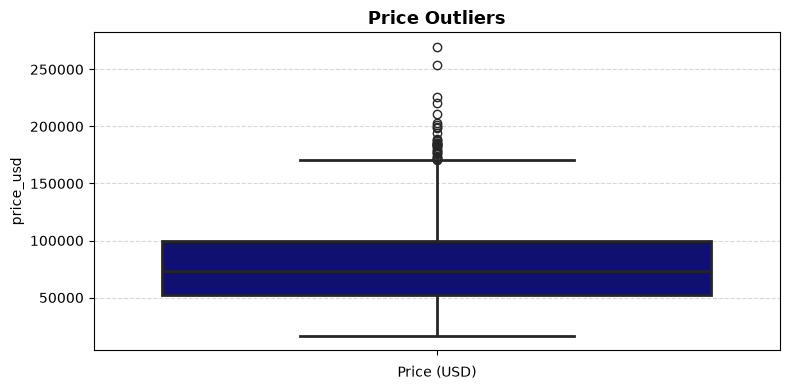

In [29]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    data= df,
    y="price_usd",
    color= 'navy',
    linewidth= 2,
    fliersize=6
)
plt.title(
    "Price Outliers",
    fontsize= 13,
    fontweight= 'bold'
)
plt.xlabel(
    "Price (USD)",
    fontsize= 10
)
plt.grid(
    axis= 'y',
    linestyle= '--',
    alpha= 0.5
)
plt.tight_layout()
plt.show()

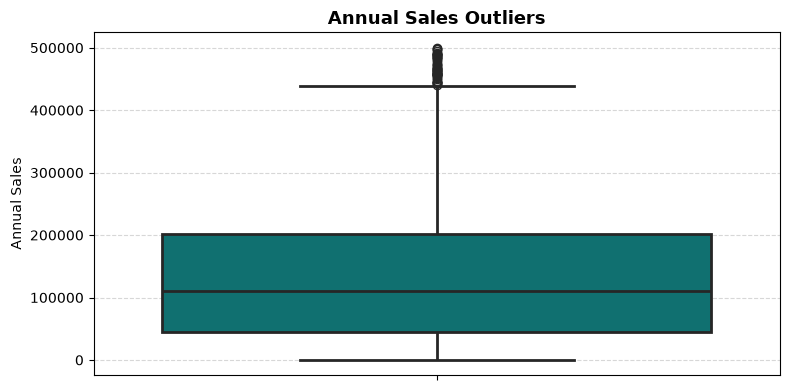

In [34]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    data= df,
    y= "annual_sales_units",
    color= 'teal',
    linewidth= 2,
    fliersize=6
)
plt.title(
    "Annual Sales Outliers",
    fontsize= 13,
    fontweight= 'bold'
)
plt.ylabel(
    "Annual Sales",
    fontsize= 10
)
plt.grid(
    axis= 'y',
    linestyle= '--',
    alpha= 0.5
)
plt.tight_layout()
plt.show()

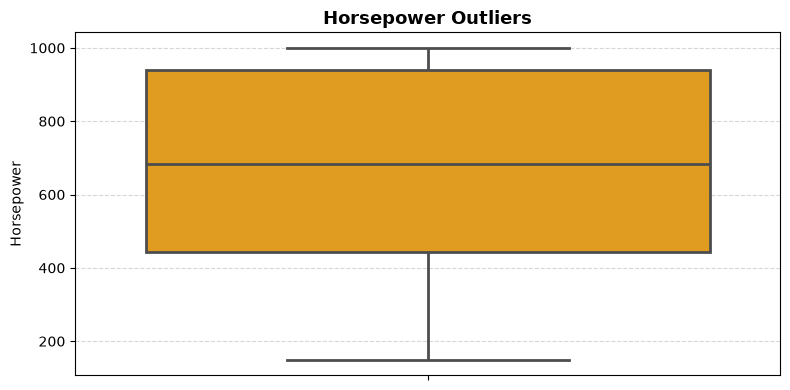

In [36]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df,
    y="horsepower",
    color= 'orange',
    linewidth= 2,
    fliersize=6
)
plt.title(
    "Horsepower Outliers",
    fontsize= 13,
    fontweight= 'bold'
)
plt.ylabel(
    "Horsepower",
    fontsize= 10
)
plt.grid(
    axis= 'y',
    linestyle= '--',
    alpha= 0.5
)
plt.tight_layout()
plt.show()

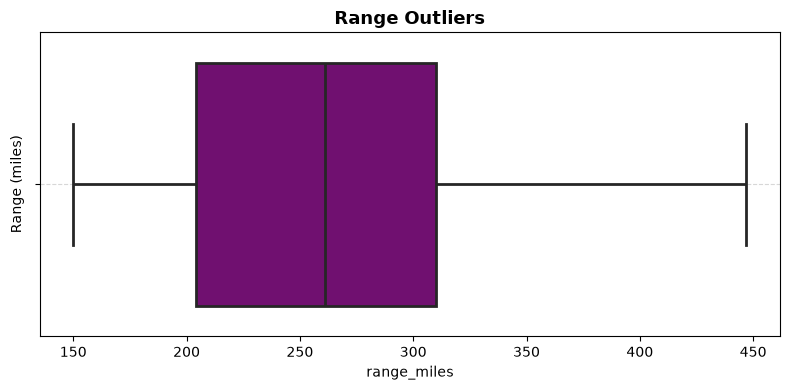

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df,
    x="range_miles",
    color= 'purple',
    linewidth= 2,
    fliersize=6
)
plt.title(
    "Range Outliers",
    fontsize= 13,
    fontweight= 'bold'
)
plt.ylabel(
    "Range (miles)",
    fontsize= 10
    )
plt.grid(
    axis= 'y',
    linestyle= '--',
    alpha= 0.5
)
plt.tight_layout()
plt.show()

In [ ]:
#Checks for possible outliers in Price column
Q1 = df["price_usd"].quantile(0.25)
Q3 = df["price_usd"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower limit:", lower.round(2))
print("Upper limit:", upper.round(2))
print("Number of price outliers:", len(outliers))

Lower limit: -18855.44
Upper limit: 170961.51
Number of price outliers: 32


In [43]:
#Checks for possible outliers in annual_sales_units column
Q1 = df["annual_sales_units"].quantile(0.25)
Q3 = df["annual_sales_units"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower limit:", lower.round(2))
print("Upper limit:", upper.round(2))
print("Number of annual_sales_units outliers:", len(outliers))

Lower limit: -193003.88
Upper limit: 439797.12
Number of annual_sales_units outliers: 32


In [44]:
#Checks for possible outliers in horsepower column
Q1 = df["horsepower"].quantile(0.25)
Q3 = df["horsepower"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower limit:", lower.round(2))
print("Upper limit:", upper.round(2))
print("Number of horsepower outliers:", len(outliers))

Lower limit: -302.0
Upper limit: 1684.0
Number of horsepower outliers: 32


In [47]:
#Checks for possible outliers in range_miles column
Q1 = df["range_miles"].quantile(0.25)
Q3 = df["range_miles"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower limit:", lower.round(2))
print("Upper limit:", upper.round(2))
print("Number of range_miles outliers:", len(outliers))

Lower limit: 45.0
Upper limit: 469.0
Number of range_miles outliers: 32


#OUTLIER HANDLING
Potential outliers were identified using the IQR method. The flagged observations were reviewed against the expected ranges of the dataset. The extreme values represented legitimate variations in vehicle specifications, pricing, and sales rather than obvious data-entry errors. Therefore, the valid observations were retained instead of being removed.

##FEATURE ENGINEERING 

In [ ]:
#Shows how efficiently the battery provides driving ranged
df["range_efficiency"] = df["range_miles"] / df["battery_capacity_kwh"]

In [52]:
#Shows the price paid for each mile of driving range
df["price_per_range_mile"] = df["price_usd"] / df["range_miles"]

In [53]:
#Measures horsepower relative to vehicle weight
df["power_to_weight"] = df["horsepower"] / df["weight_kg"]

In [54]:
#Measures torque relative to vehicle weight
df["torque_to_weight"] = df["torque_nm"] / df["weight_kg"]

In [55]:
#Shows battery capacity relative to vehicle weight
df["battery_to_weight"] = df["battery_capacity_kwh"] / df["weight_kg"]

In [57]:
#Calculate the age of each vehicle
df["vehicle_age"] = 2026 - df["year"]

In [59]:
#Check feature engineering
df[[
    "range_efficiency",
    "price_per_range_mile",
    "power_to_weight",
    "torque_to_weight",
    "battery_to_weight",
    "vehicle_age"
]].head()

,range_efficiency,price_per_range_mile,power_to_weight,torque_to_weight,battery_to_weight,vehicle_age
0,3.369840,262.202000,0.496278,0.444169,0.058908,3
1,3.724490,220.170822,0.222937,0.210650,0.034406,4
2,3.865979,220.671644,0.383562,0.336595,0.037965,2
3,3.404878,109.259484,0.160207,0.168992,0.052972,2
4,3.343983,458.853089,0.448632,0.396142,0.042127,4


##CATEGORICAL ENCODING

In [61]:
#Encoding categorical columns
df = pd.get_dummies(
    df,
    columns=["drive_type", "body_type", "country_of_origin", "market_segment"],
    drop_first=True
)

In [73]:
df = pd.get_dummies(
    df,
    columns=["variant"],
    drop_first=True
)

In [63]:
#Encoding brand column
df = pd.get_dummies(
    df,
    columns=["brand"],
    drop_first=True
)

##STANDARDIZATION

In [81]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

columns = [
    "battery_capacity_kwh",
    "range_miles",
    "charging_speed_kw",
    "acceleration_0_60_mph",
    "top_speed_mph",
    "horsepower",
    "torque_nm",
    "weight_kg",
    "annual_sales_units",
    "customer_rating",
    "warranty_years"
]

df[columns] = scaler.fit_transform(df[columns])

##FINAL VALIDATION

In [75]:
df.shape

(2000, 62)

In [76]:
df.isnull().sum().sum()

np.int64(0)

In [77]:
df.duplicated().sum()

np.int64(0)

In [78]:
df.head()

,model,year,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,horsepower,torque_nm,...,brand_Rivian,brand_Tesla,brand_Toyota,brand_Volkswagen,brand_Volvo,brand_Xiaomi,variant_Long Range,variant_Performance,variant_Premium,variant_Standard
0,ID. Buzz,2023,104880.80,118.7,400.0,234.5,3.04,195.0,1000.0,895.0,...,False,False,False,True,False,False,False,True,False,False
1,bZ Compact SUV,2022,48217.41,58.8,219.0,148.1,5.77,159.0,381.0,360.0,...,False,False,True,False,False,False,False,False,True,False
2,Bolt EV,2024,49651.12,58.2,225.0,104.9,6.84,148.0,588.0,516.0,...,False,False,False,False,False,False,False,False,True,False
3,Sportage EV,2024,38131.56,102.5,349.0,66.5,4.66,176.0,310.0,327.0,...,False,False,False,False,False,False,True,False,False,False
4,Model 3,2022,144079.87,93.9,314.0,298.5,5.64,165.0,1000.0,883.0,...,False,True,False,False,False,False,True,False,False,False


In [80]:
df.columns.tolist()

['model',
 'year',
 'price_usd',
 'battery_capacity_kwh',
 'range_miles',
 'charging_speed_kw',
 'acceleration_0_60_mph',
 'top_speed_mph',
 'horsepower',
 'torque_nm',
 'seating_capacity',
 'cargo_volume_cubic_ft',
 'weight_kg',
 'safety_rating',
 'autopilot_level',
 'annual_sales_units',
 'customer_rating',
 'warranty_years',
 'range_efficiency',
 'price_per_range_mile',
 'power_to_weight',
 'torque_to_weight',
 'battery_to_weight',
 'vehicle_age',
 'drive_type_FWD',
 'drive_type_RWD',
 'body_type_Hatchback',
 'body_type_SUV',
 'body_type_Sedan',
 'body_type_Truck',
 'body_type_Van',
 'country_of_origin_Germany',
 'country_of_origin_Japan',
 'country_of_origin_South Korea',
 'country_of_origin_Sweden',
 'country_of_origin_US',
 'market_segment_Luxury',
 'market_segment_Mid-range',
 'market_segment_Premium',
 'brand_BMW',
 'brand_BYD',
 'brand_Fisker',
 'brand_Ford',
 'brand_GM/Chevrolet',
 'brand_Honda',
 'brand_Hyundai',
 'brand_Kia',
 'brand_Lucid',
 'brand_Mercedes',
 'brand_NIO',

In [79]:
df.to_csv("EV_Market_Cleaned.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!
